# MIS780 Advanced AI For Business - Assessment 2 - T2 2025

## Task Number 2: Image-Based Recyclable Material Classification

**Student Name:** Quang Huy Le

**Student ID:** 224279168

## Table of Content

1. [Executive Summary](#cell_Summary)

2. [Data Preprocessing](#cell_Preprocessing)

3. [Predictive Modeling](#cell_model)

4. [Experiments Report](#cell_report)

5. [Role of GenAI](#cell_GenAI)



<a id = "cell_Summary"></a>
## 1. Executive Summary

This report addresses the business challenge of improving efficiency in recycling facilities through material classification. A dataset of 2691 real-world images across six recyclable categories: cardboard, clothes, green glass, metal, paper, and white glass, was analyzed to develop a reliable deep learning model for material sorting.

Following standard pre-processing steps, multiple convolutional neural network (CNN) architectures were designed and evaluated with variations in kernel, hidden layers, and dropout. Experimental results demonstrated that shallow CNNs performed better than very deep or large-kernel models, but the most effective solution was a balanced design combining double convolutional layers per block with dropout regularization.

The final model (CNN-DoubleConv-MP-30-60-90-Flat-120D-Dr0.5) achieved 74.8% test accuracy and a test loss of 0.8023, outperforming all other alternatives. Class-level analysis showed that green glass was consistently recognized with the highest precision, while white glass underperformed due to visual similarities with paper and metal.

The findings highlight that CNN-based solutions can significantly enhance automated recycling systems by reducing misclassification and improving sorting accuracy. Potential improvements include expanding the dataset, applying advanced augmentation, and leveraging transfer learning. Together, these measures would support more sustainable recycling operations and contribute to the broader goal of the economy.

<a id = "cell_Preprocessing"></a>
## 2. Data Preprocessing

In [1]:
%%html
<style>table {float:left}</style>
<style>img {float:left}</style>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow import keras
import tensorflow as tf
import math
import os
import keras
from sklearn.utils import check_random_state

os.environ['TF_NUM_INTEROP_THREADS'] = '1'
os.environ['TF_NUM_INTRAOP_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
os.environ['PYTHONHASHSEED'] = str(149)
#Import all required libraries
# Set Seeds for Reproducibility
seed = 149
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)
rng = check_random_state(149)
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
from google.colab import drive
#it will open a webpage for verifying your google account. if it is successful, the Google colab can link the Google drive
drive.mount('/content/drive')

# to show the folders under the dataset
!ls "/content/drive/My Drive/Colab Notebooks/Task 2 Dataset Recyclable Material/"

Mounted at /content/drive
cardboard  clothes  green-glass  metal	paper  white-glass


In [4]:
def plot_images(ims, figsize=(12,12), cols=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        if (ims.shape[-1] != 3):
            ims = ims = ims[:,:,:,0]
    f = plt.figure(figsize=figsize)
    rows=len(ims)//cols if len(ims) % cols == 0 else len(ims)//cols + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [5]:
def plot_hist(h, xsize=6, ysize=5):
    # Prepare plotting
    fig_size = plt.rcParams["figure.figsize"]
    plt.rcParams["figure.figsize"] = [xsize, ysize]

    # Get training and validation keys
    ks = list(h.keys())
    n2 = math.floor(len(ks)/2)
    train_keys = ks[0:n2]
    valid_keys = ks[n2:2*n2]

    # summarize history for different metrics
    for i in range(n2):
        plt.plot(h[train_keys[i]])
        plt.plot(h[valid_keys[i]])
        plt.title('Training vs Validation '+train_keys[i])
        plt.ylabel(train_keys[i])
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
        plt.draw()
        plt.show()

    return

In [6]:
# Set the paths to the folders containing the image files
cardboard_path = '/content/drive/MyDrive/Colab Notebooks/Task 2 Dataset Recyclable Material/cardboard'
clothes_path = '/content/drive/MyDrive/Colab Notebooks/Task 2 Dataset Recyclable Material/clothes'
greenglass_path = '/content/drive/MyDrive/Colab Notebooks/Task 2 Dataset Recyclable Material/green-glass'
metal_path = '/content/drive/MyDrive/Colab Notebooks/Task 2 Dataset Recyclable Material/metal'
paper_path = '/content/drive/MyDrive/Colab Notebooks/Task 2 Dataset Recyclable Material/paper'
whiteglass_path = '/content/drive/MyDrive/Colab Notebooks/Task 2 Dataset Recyclable Material/white-glass'

# get a list of all files in the folder
cardboard_file_list = os.listdir(cardboard_path)
clothes_file_list = os.listdir(clothes_path)
greenglass_file_list = os.listdir(greenglass_path)
metal_file_list = os.listdir(metal_path)
paper_file_list = os.listdir(paper_path)
whiteglass_file_list = os.listdir(whiteglass_path)

# print the total number of files
print(f'Total number of files under cardboard folder are: {len(cardboard_file_list)}')
print(f'Total number of files under clothes folder are: {len(clothes_file_list)}')
print(f'Total number of files under green-glass folder are: {len(greenglass_file_list)}')
print(f'Total number of files under metal folder are: {len(metal_file_list)}')
print(f'Total number of files under paper folder are: {len(paper_file_list)}')
print(f'Total number of files under white-glass folder are: {len(whiteglass_file_list)}')

Total number of files under cardboard folder are: 417
Total number of files under clothes folder are: 511
Total number of files under green-glass folder are: 449
Total number of files under metal folder are: 430
Total number of files under paper folder are: 479
Total number of files under white-glass folder are: 405


The dataset contains 2691 images across the following classes: cardboard (417), clothes (511), green-glass (449), metal (430), paper (479), white-glass (405). In percentage terms: cardboard 15.50%, clothes 18.99%, green-glass 16.69%, metal 15.98%, paper 17.80%, white-glass 15.05% of the dataset. The distribution is moderately imbalanced, with clothes and paper slightly over-represented.

In [7]:
# Create a list to store the image data and labels
data = []

# Iterate through the files in the first folder
for file in os.listdir(cardboard_path):
  # Check if the file is a jpeg or jpg file
  if file.endswith('.jpeg') or file.endswith('.jpg'):
    # Load the image data from the file using TensorFlow
    img = tf.io.read_file(os.path.join(cardboard_path, file))
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img, (100, 100))
    # Assign a label to the file
    label = 'cardboard'
    # Add the image data and label to the data list
    data.append((img, label))

# Iterate through the files in the second folder
for file in os.listdir(clothes_path):
  # Check if the file is a jpeg or jpg file
  if file.endswith('.jpeg') or file.endswith('.jpg'):
    # Load the image data from the file using TensorFlow
    img = tf.io.read_file(os.path.join(clothes_path, file))
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img, (100, 100))
    # Assign a label to the file
    label = 'clothes'
    # Add the image data and label to the data list
    data.append((img, label))

# Iterate through the files in the third folder
for file in os.listdir(greenglass_path):
  # Check if the file is a jpeg or jpg file
  if file.endswith('.jpeg') or file.endswith('.jpg'):
    # Load the image data from the file using TensorFlow
    img = tf.io.read_file(os.path.join(greenglass_path, file))
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img, (100, 100))
    # Assign a label to the file
    label = 'greenglass'
    # Add the image data and label to the data list
    data.append((img, label))

# Iterate through the files in the fourth folder
for file in os.listdir(metal_path):
  # Check if the file is a jpeg or jpg file
  if file.endswith('.jpeg') or file.endswith('.jpg'):
    # Load the image data from the file using TensorFlow
    img = tf.io.read_file(os.path.join(metal_path, file))
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img, (100, 100))
    # Assign a label to the file
    label = 'metal'
    # Add the image data and label to the data list
    data.append((img, label))

# Iterate through the files in the fifth folder
for file in os.listdir(paper_path):
  # Check if the file is a jpeg or jpg file
  if file.endswith('.jpeg') or file.endswith('.jpg'):
    # Load the image data from the file using TensorFlow
    img = tf.io.read_file(os.path.join(paper_path, file))
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img, (100, 100))
    # Assign a label to the file
    label = 'paper'
    # Add the image data and label to the data list
    data.append((img, label))

# Iterate through the sixth in the second folder
for file in os.listdir(whiteglass_path):
  # Check if the file is a jpeg or jpg file
  if file.endswith('.jpeg') or file.endswith('.jpg'):
    # Load the image data from the file using TensorFlow
    img = tf.io.read_file(os.path.join(whiteglass_path, file))
    img = tf.image.decode_jpeg(img,channels=3)
    img = tf.image.resize(img, (100, 100))
    # Assign a label to the file
    label = 'whiteglass'
    # Add the image data and label to the data list
    data.append((img, label))

In [8]:
# Shuffle the data and split into train/test sets
random.seed(149)
random.shuffle(data)
train_data, test_data = data[:int(len(data) * 0.7)], data[int(len(data) * 0.7):]

In [9]:
# Extract the image data and labels from the training data
X_train, Y_train = zip(*train_data)

# Extract the image data and labels from the testing data
X_test, Y_test = zip(*test_data)

# Convert the image data and labels into NumPy arrays
X_train = np.array(X_train)
Y_train = np.array(Y_train)
X_test = np.array(X_test)
Y_test = np.array(Y_test)

In [10]:
# change integers to 32-bit floating point numbers
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# normalize each value for each pixel for the entire vector for each input
X_train /= 255
X_test /= 255

# print the shape of the reshaped data
print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (1883, 100, 100, 3)
Testing matrix shape (808, 100, 100, 3)


In [11]:
print('The original format of class of the first element in the training dataset is: ',Y_train[0], '\n')

import numpy as np
# Create a NumPy array with category strings
categories = np.array(['cardboard', 'clothes', 'greenglass', 'metal', 'paper', 'whiteglass'])

# Create a mapping from category strings to integers
category_map = {'cardboard': 0, 'clothes': 1, 'greenglass': 2, 'metal': 3, 'paper': 4, 'whiteglass': 5}

# Encode the categories
Y_train = np.array([category_map[category] for category in Y_train])
Y_test = np.array([category_map[category] for category in Y_test])

print('The unique integer mapping encoding format of the class of the first element in the training dataset is: ',Y_train[0])

The original format of class of the first element in the training dataset is:  paper 

The unique integer mapping encoding format of the class of the first element in the training dataset is:  4


To ensure reproducibility and an unbiased estimate of generalization performance, the dataset was randomly shuffled with a fixed seed (149) and partitioned into 70% training (1,883 images) and 30% testing (808 images).

All images were cast to 32-bit floating point and normalized by dividing pixel values by 255. This standardization places inputs on a consistent numerical scale, and stabilizes optimizer behavior across different models. Class labels were mapped to stable integer identifiers in a fixed order: cardboard (0), clothes (1), greenglass (2), metal (3), paper (4), whiteglass (5), so that metrics, confusion matrices, and deployment outputs remain consistent and interpretable across experiments.

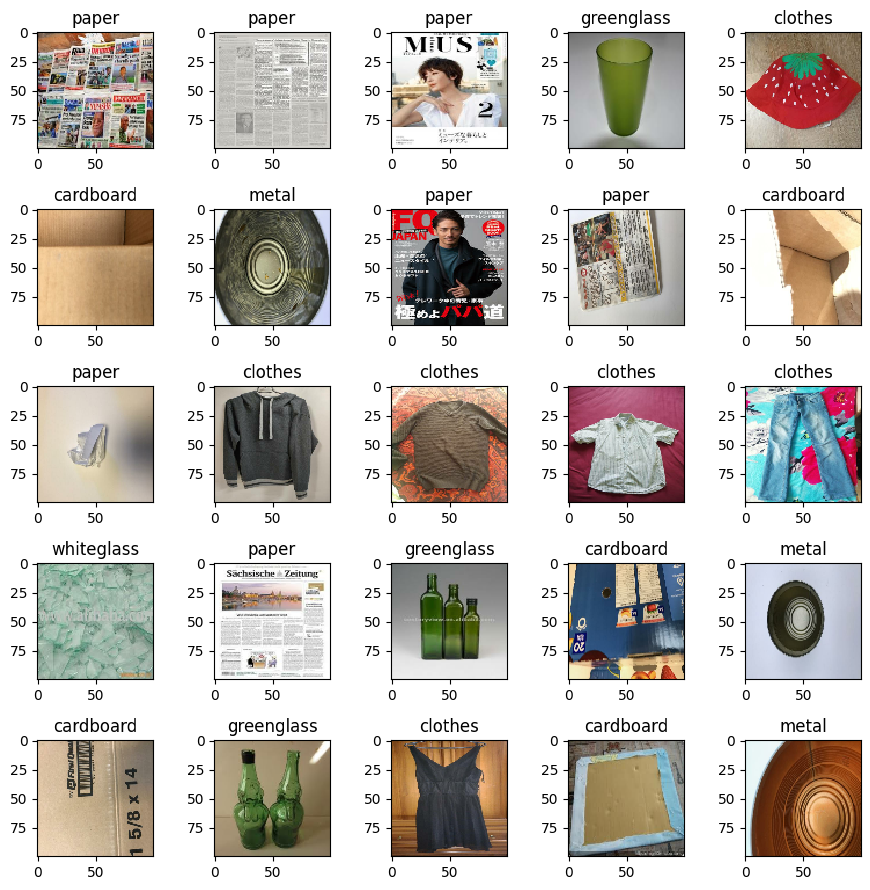

In [12]:
# change the default figure size for all plots created in the program
plt.rcParams['figure.figsize'] = (9,9)

labels =  ['cardboard', 'clothes', 'greenglass', 'metal', 'paper', 'whiteglass']

for i in range(25):
    # plt.subplot() function takes three integer arguments: the number of rows, the number of columns, and the index of the subplot.
    plt.subplot(5,5,i+1)
    # plt.imshow() function displays the image at index i in the X_train array as a grayscale image, with no interpolation applied.
    plt.imshow(X_train[i], interpolation='none')
    plt.title("{}".format(labels[int(Y_train[i])]))

plt.tight_layout()

<a id = "cell_model"></a>
## 3. Predictive Modeling

*Create and explain your models (e.g., model architecture, model parameters). Evaluate the models on the experimental data sets.*

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Flatten
from tensorflow.keras.layers import MaxPooling2D, Activation, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard, Callback, EarlyStopping
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Nadam
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras import regularizers

In [14]:
# Data parameters
img_rows, img_cols = 100, 100
channels = 3

num_classes = 6
class_names = ['cardboard', 'clothes','greenglass',
               'metal','paper','whiteglass']

In [15]:
from tensorflow.keras.utils import to_categorical

# Convert class vectors to binary class matrices
Y_train = to_categorical(Y_train, num_classes)
Y_test = to_categorical(Y_test, num_classes)

print('Train shape: x=', X_train.shape, ', y=', Y_train.shape)
print('Test shape: x=', X_test.shape, ', y=', Y_test.shape)

Train shape: x= (1883, 100, 100, 3) , y= (1883, 6)
Test shape: x= (808, 100, 100, 3) , y= (808, 6)


In [16]:
#Model building

def model_15():
    model = Sequential()
    model.add(Conv2D(30, (3,3), padding='same', input_shape=(img_rows, img_cols, channels)))
    model.add(Activation('relu'))
    model.add(Conv2D(30, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(60, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(Conv2D(60, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(90, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(120, activation='relu'))
    model.add(Dropout(0.50))
    model.add(Dense(num_classes, activation='softmax'))
    model.summary(); return model

In [17]:
# Keras callbacks (when Tensorboard installed)
keras_callbacks = [EarlyStopping(monitor='val_loss', patience=3, verbose=0)]

In [18]:
# Model summary
model = model_15()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 100, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 30)   │         8,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100, 100, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 60)     │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 50, 50, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 60)     │        32,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 50, 50, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 90)     │        48,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 25, 25, 90)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 90)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12960)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │     1,555,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,662,426 (6.34 MB)

 Trainable params: 1,662,426 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile and fit the model

model.compile(loss=categorical_crossentropy,
              optimizer=RMSprop(learning_rate=0.001,weight_decay=1e-6),
              metrics=['accuracy'])

hist = model.fit(X_train, Y_train,
      batch_size=128,
      epochs=30,
      verbose=2,
      validation_data=(X_test, Y_test),
      validation_split=0.2,
      callbacks=keras_callbacks)

Epoch 1/30
15/15 - 7s - 481ms/step - accuracy: 0.1992 - loss: 1.9842 - val_accuracy: 0.2277 - val_loss: 1.7449
Epoch 2/30
15/15 - 6s - 427ms/step - accuracy: 0.3001 - loss: 1.6460 - val_accuracy: 0.2178 - val_loss: 1.7509
Epoch 3/30
15/15 - 2s - 115ms/step - accuracy: 0.4180 - loss: 1.4921 - val_accuracy: 0.5780 - val_loss: 1.2708
Epoch 4/30
15/15 - 2s - 115ms/step - accuracy: 0.4976 - loss: 1.3334 - val_accuracy: 0.5743 - val_loss: 1.1673
Epoch 5/30
15/15 - 2s - 114ms/step - accuracy: 0.5736 - loss: 1.1620 - val_accuracy: 0.6188 - val_loss: 1.0967
Epoch 6/30
15/15 - 2s - 112ms/step - accuracy: 0.5943 - loss: 1.1308 - val_accuracy: 0.5136 - val_loss: 1.1845
Epoch 7/30
15/15 - 2s - 114ms/step - accuracy: 0.5459 - loss: 1.3252 - val_accuracy: 0.6782 - val_loss: 1.0205
Epoch 8/30
15/15 - 3s - 179ms/step - accuracy: 0.6984 - loss: 0.8991 - val_accuracy: 0.6485 - val_loss: 1.0168
Epoch 9/30
15/15 - 2s - 124ms/step - accuracy: 0.6452 - loss: 1.0204 - val_accuracy: 0.6968 - val_loss: 0.9159
E

A baseline MLP model was initially constructed, followed by a systematic evaluation of multiple CNN variants with different kernel sizes, layer depths, batch normalization, and dropout configurations. The intent was to identify the architecture that achieved the highest generalization performance on the test set.

The final solution selected was a CNN architecture with double convolutional layers per block, referred to as CNN-DoubleConv-MP-30-60-90-Flat-120D-Dr0.5. This model achieved the strongest performance across all experiments, with a test accuracy of 0.7475, substantially higher than other alternative architectures.

The model was built with three main convolutional stages, each stage containing two filters followed by pooling to gradually capture patterns and reduce noise. After feature extraction, the network connected to a fully connected layer of 120 units with dropout, before producing the six output classes using softmax activation. This layered structure allowed the model to balance detail recognition with overall generalization.

The training process used the RMSprop optimizer with a learning rate of 0.001 and a small weight decay, which helped stabilize learning. Training was run for a maximum of 30 epochs, but early stopping with patience of 3 prevented unnecessary training once validation results stopped improving. A batch size of 128 was chosen to make the most of computational efficiency while keeping the learning stable.

In [20]:
# Evaluate on training data
train_score = model.evaluate(X_train, Y_train, verbose=0)
print('Train loss:', round(train_score[0], 4))
print('Train accuracy:', round(train_score[1], 4), '\n')

# Evaluate on test data
test_score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', round(test_score[0], 4))
print('Test accuracy:', round(test_score[1], 4))

Train loss: 0.2867
Train accuracy: 0.8954 

Test loss: 0.8023
Test accuracy: 0.7475



The final model achieved 0.895 training accuracy and 0.7475 test accuracy, with a corresponding test loss of 0.8023. This indicates that while the model performs strongly overall, there remains some uncertainty in predictions, particularly for visually similar classes.

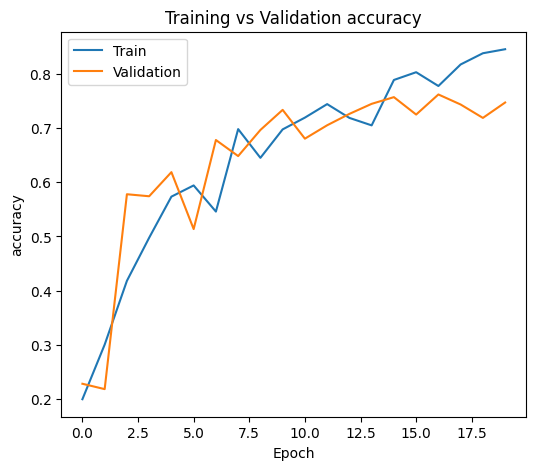

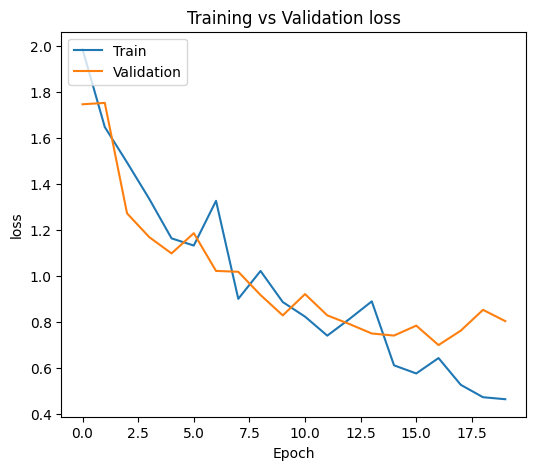

In [21]:
# Plot history of learning
import pandas as pd

plot_hist(pd.DataFrame(hist.history))

The learning curves confirm this performance. Training and validation accuracy rose consistently, with validation accuracy stabilizing at around 75%. The loss curves also show steady improvement, with validation loss levelling off near 0.8, reflecting a reasonable balance between learning and generalization.

In [22]:
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score

# Make predictions on the test set
Y_pred = model.predict(X_test)

# Convert the predicted labels to continuous-multioutput format
Y_pred_continuous = np.round(Y_pred)

# Convert the predicted labels to multiclass format
Y_pred_multiclass = np.argmax(Y_pred, axis=1)
Y_test_multiclass = np.argmax(Y_test, axis=1)

# Calculate the kappa score
kappa = cohen_kappa_score(Y_test_multiclass, Y_pred_multiclass)
print("The result of Kappa is :", round(kappa, 3))

# Generate the classification report
report = classification_report(Y_test_multiclass, Y_pred_multiclass, target_names= class_names)

# Print the report
print("The result of the classification report is: \n ",report)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
The result of Kappa is : 0.697
The result of the classification report is: 
                precision    recall  f1-score   support

   cardboard       0.81      0.71      0.76       128
     clothes       0.87      0.70      0.78       157
  greenglass       0.96      0.93      0.94       137
       metal       0.66      0.60      0.63       133
       paper       0.63      0.82      0.71       135
  whiteglass       0.60      0.71      0.65       118

    accuracy                           0.75       808
   macro avg       0.76      0.75      0.75       808
weighted avg       0.76      0.75      0.75       808



The classification report provides further insight. Green glass recorded the highest scores (precision 0.96, recall 0.93, F1-score 0.94), suggesting it is the easiest class to recognize. Clothes also performed well, with an F1-score of 0.78. Conversely, metal, paper, and white glass showed lower results, with F1-scores of 0.63, 0.71, and 0.65 respectively.

Among the six classes, white glass demonstrated the weakest performance, with a precision of 0.60, recall of 0.71, and an F1-score of 0.65. This was lower than all other categories, as also confirmed by the confusion matrix, where white glass was often misclassified.

The main reason for this underperformance may lie in its visual similarity to other materials. Transparent and reflective surfaces, such as white glass, often share brightness, edges, and textures with metallic objects or light-colored paper, making them difficult for the model to distinguish.

In [23]:
Y_pred

array([[2.45474696e-10, 5.05048206e-07, 1.80190047e-11, 6.15007707e-08,
        9.99999404e-01, 3.33614802e-10],
       [1.17013515e-04, 8.83423141e-04, 7.25471546e-06, 1.32476140e-04,
        9.98414874e-01, 4.44856210e-04],
       [2.36584485e-01, 3.07472097e-03, 1.55952026e-03, 3.43742311e-01,
        6.98178634e-03, 4.08057153e-01],
       ...,
       [3.66299481e-18, 2.09726984e-12, 1.00000000e+00, 9.29150527e-20,
        3.48827967e-15, 6.00237828e-16],
       [9.99892473e-01, 2.28745171e-06, 3.68329523e-07, 1.57014233e-06,
        3.44989166e-05, 6.88956861e-05],
       [9.97538209e-01, 9.78340977e-04, 2.88759816e-06, 3.26755922e-04,
        8.15527630e-04, 3.38275073e-04]], dtype=float32)

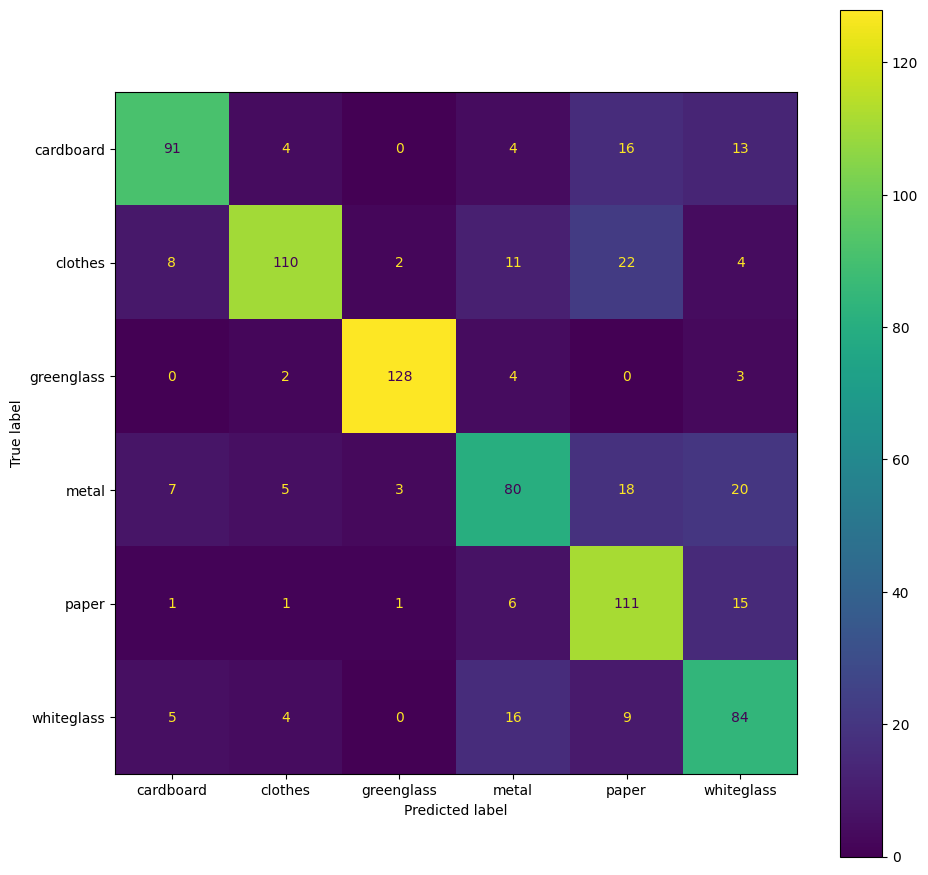

In [24]:
# Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    Y_test_multiclass,
    Y_pred_multiclass)

# Create a ConfusionMatrixDisplay object
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names)

# Create a figure with a larger size
fig = plt.figure(figsize=(11, 11))

# Create a subplot within the figure
ax = fig.subplots()

# Plot the confusion matrix as a heatmap
display.plot(ax=ax)

# Show the plot
plt.show()

The confusion matrix shows clear strengths and weaknesses. Green glass was classified reliably. However, metal and white glass were misclassified more frequently. This highlights the challenge of distinguishing materials with similar brightness and textures.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


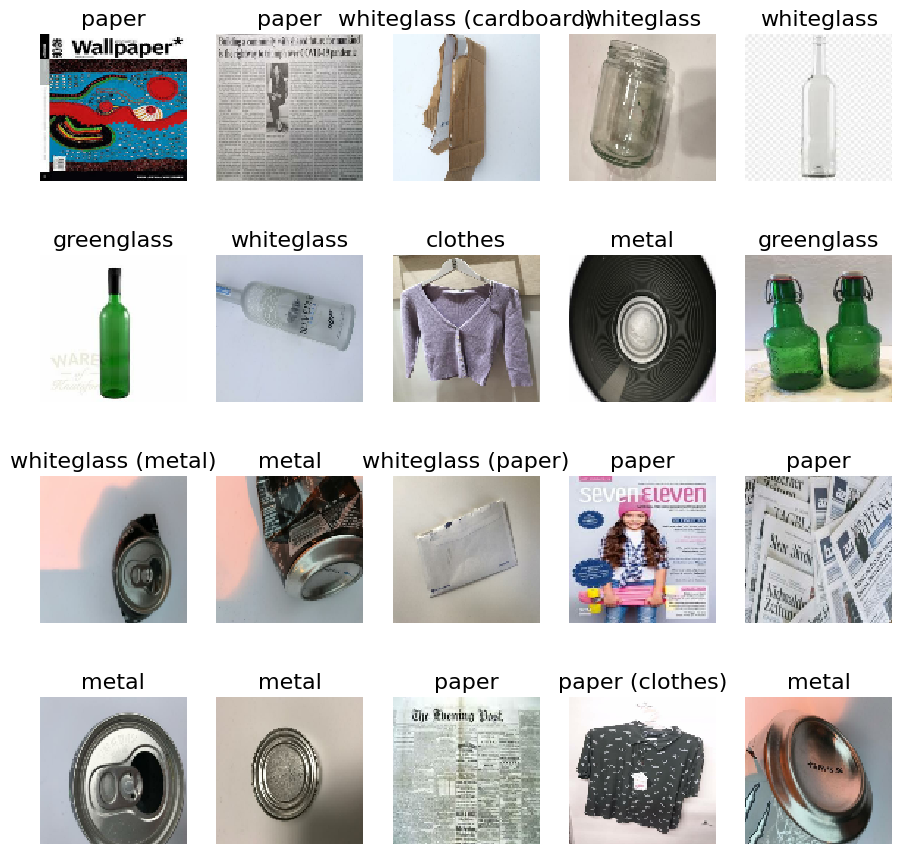

In [25]:
# Sample prediction

img_range = range(20)
imgs = X_test[img_range]
true_labels = [class_names[np.argmax(x)] for x in Y_test[img_range]]
predictions = model.predict(imgs.reshape(len(img_range), img_rows, img_cols, channels))
pred_labels = [class_names[np.argmax(x)] for x in predictions]
titles = [pred_labels[x]+('' if true_labels[x] == pred_labels[x] else ' ('+true_labels[x]+')') for x in img_range]
plot_images(imgs, cols=5, figsize=(11,11), titles=titles)

<a id = "cell_report"></a>
## 4. Experiments Report

In [26]:
import pandas as pd
from io import StringIO

data_str = """Model,Train Loss,Train Accuracy,Test Loss,Test Accuracy
Baseline-MLP-128,1.7864,0.1891,1.7893,0.1918
CNN-2Block-32-64-Flat-128D-Dr0.5,0.2734,0.9150,0.8722,0.7389
CNN-2BlockBN-32-64-Flat-128D-Dr0.5,1.5733,0.3792,1.5941,0.4010
CNN-K5First-32-64-Flat-128D-Dr0.4,1.7359,0.2130,1.7307,0.1950
CNN-3BlockBN-32-64-128-Flat-256D-Dr0.5,2.0497,0.1880,2.1023,0.1807
CNN-3BlockBN-25-50-100-Flat-150D-Dr0.3,2.0321,0.1524,2.0501,0.1460
CNN-K5First-50-75-Flat-150D-Dr0.4,2.8554,0.1779,2.8567,0.1621
CNN-NoPoolfor2Earlylayers-50-75-100-BN-Flat-120D-Dr0.45,1.8310,0.1593,1.8375,0.1559
CNN-AsymK-1x7-7x1-50-50-100-Flat-100D-Dr0.35,1.2740,0.5454,1.3016,0.5235
CNN-K5First-75-100-Flat-150D-Dr0.5,1.7805,0.3595,1.8342,0.3453
CNN-2BlockBN-25-50-100-Flat-120D-60D-Dr0.45_0.3,1.6866,0.2762,1.6949,0.2797
CNN-3BlockBN-32-64-128-Flat-256D-Dr0.3,2.1915,0.1609,2.1856,0.1621
CNN-2Block-40-80-Flat-160D-Dr0.5,0.2794,0.9065,0.8110,0.7364
CNN-3Block-60K5-90-120-Flat-180D-Dr0.45,0.6383,0.7700,0.9759,0.6795
CNN-DoubleConv-MP-30-60-90-Flat-120D-Dr0.5,0.2867,0.8954,0.8023,0.7475
"""

# Load into DataFrame
model_table = pd.read_csv(StringIO(data_str))

# Display as table (centered)
model_table.style.set_properties(**{'text-align': 'center'})

,Model,Train Loss,Train Accuracy,Test Loss,Test Accuracy
0,Baseline-MLP-128,1.786400,0.189100,1.789300,0.191800
1,CNN-2Block-32-64-Flat-128D-Dr0.5,0.273400,0.915000,0.872200,0.738900
2,CNN-2BlockBN-32-64-Flat-128D-Dr0.5,1.573300,0.379200,1.594100,0.401000
3,CNN-K5First-32-64-Flat-128D-Dr0.4,1.735900,0.213000,1.730700,0.195000
4,CNN-3BlockBN-32-64-128-Flat-256D-Dr0.5,2.049700,0.188000,2.102300,0.180700
5,CNN-3BlockBN-25-50-100-Flat-150D-Dr0.3,2.032100,0.152400,2.050100,0.146000
6,CNN-K5First-50-75-Flat-150D-Dr0.4,2.855400,0.177900,2.856700,0.162100
7,CNN-NoPoolfor2Earlylayers-50-75-100-BN-Flat-120D-Dr0.45,1.831000,0.159300,1.837500,0.155900
8,CNN-AsymK-1x7-7x1-50-50-100-Flat-100D-Dr0.35,1.274000,0.545400,1.301600,0.523500
9,CNN-K5First-75-100-Flat-150D-Dr0.5,1.780500,0.359500,1.834200,0.345300


To identify the most effective model for recyclable material classification, a series of architectures were tested, ranging from a simple MLP baseline to more complex CNNs with varying kernel sizes, numbers of convolutional blocks, and regularization strategies. The results are summarized in the table above.

The baseline MLP performed very poorly (nearly 19% test accuracy), confirming that dense layers alone cannot extract useful features from image data.

The addition of convolutional layers improved results significantly. For example, CNN-2Block-32-64-Flat-128D-Dr0.5 achieved 73.9% test accuracy, demonstrating that even shallow CNNs provide a strong advantage. However, models with excessive depth (CNN-3BlockBN-32-64-128-Flat-256D-Dr0.3) or very large kernels (CNN-K5First variants) underperformed, with accuracies often below 20%. These architectures overfit to the training set or struggled to learn discriminative features. Intermediate models such as CNN-AsymK-1x7-7x1-50-50-100 performed moderately well (52% accuracy), but lacked robustness across all classes.

The best-performing architecture was CNN-DoubleConv-MP-30-60-90-Flat-120D-Dr0.5, which achieved 74.8% test accuracy with the lowest test loss (0.8023). This success stems from its double convolution blocks that captured image patterns before pooling. Combined with dropout (0.5), RMSprop optimization, and early stopping, this model struck the best balance between complexity and generalization.

In [27]:
from google.colab import files
from IPython.display import Image
upload = files.upload()

Saving Model 1_CM.png to Model 1_CM.png
Saving Model 1_TrainvsTestAccuracy.png to Model 1_TrainvsTestAccuracy.png
Saving Model 1_TrainvsTestLoss.png to Model 1_TrainvsTestLoss.png
Saving Model 2_CM.png to Model 2_CM.png
Saving Model 2_TrainvsTestAccuracy.png to Model 2_TrainvsTestAccuracy.png
Saving Model 2_TrainvsTestLoss.png to Model 2_TrainvsTestLoss.png
Saving Model 3_CM.png to Model 3_CM.png
Saving Model 3_TrainvsTestAccuracy.png to Model 3_TrainvsTestAccuracy.png
Saving Model 3_TrainvsTestLoss.png to Model 3_TrainvsTestLoss.png
Saving Model 4_CM.png to Model 4_CM.png
Saving Model 4_TrainvsTestAccuracy.png to Model 4_TrainvsTestAccuracy.png
Saving Model 4_TrainvsTestLoss.png to Model 4_TrainvsTestLoss.png
Saving Model 5_CM.png to Model 5_CM.png
Saving Model 5_TrainvsTestAccuracy.png to Model 5_TrainvsTestAccuracy.png
Saving Model 5_TrainvsTestLoss.png to Model 5_TrainvsTestLoss.png
Saving Model 6_CM.png to Model 6_CM.png
Saving Model 6_TrainvsTestAccuracy.png to Model 6_TrainvsTes

Displaying: Model 1_CM.png


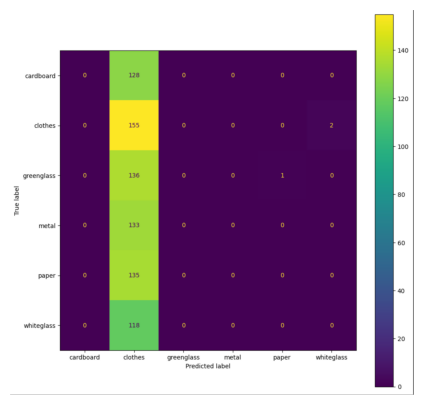

Displaying: Model 1_TrainvsTestAccuracy.png


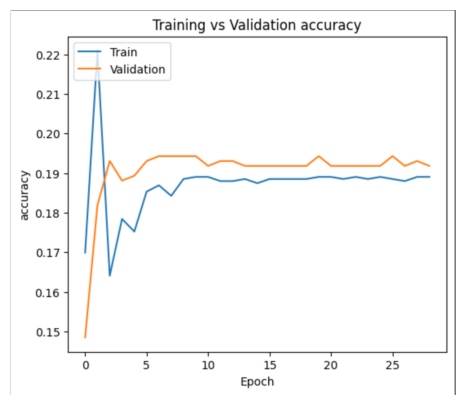

Displaying: Model 1_TrainvsTestLoss.png


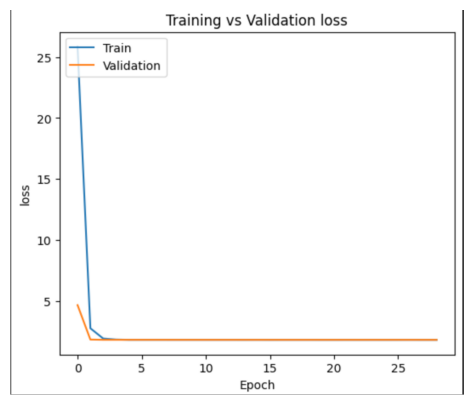

Displaying: Model 2_CM.png


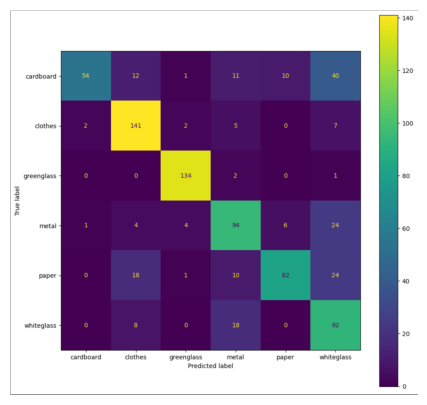

Displaying: Model 2_TrainvsTestAccuracy.png


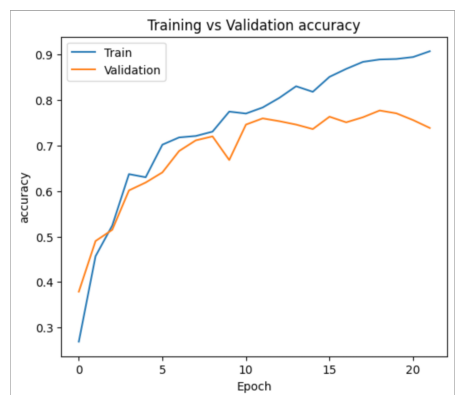

Displaying: Model 2_TrainvsTestLoss.png


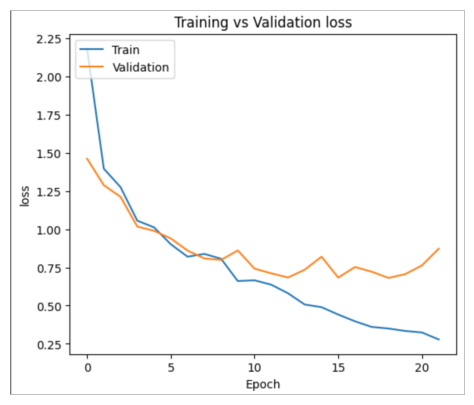

Displaying: Model 3_CM.png


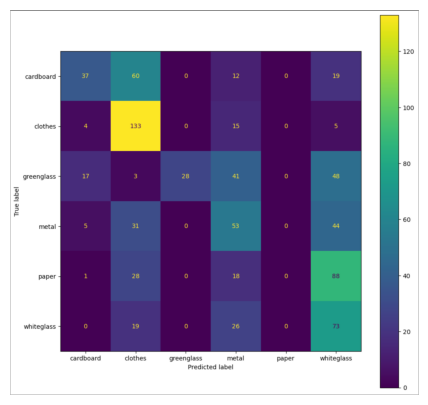

Displaying: Model 3_TrainvsTestAccuracy.png


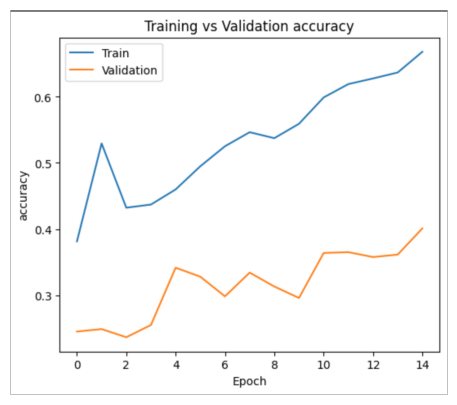

Displaying: Model 3_TrainvsTestLoss.png


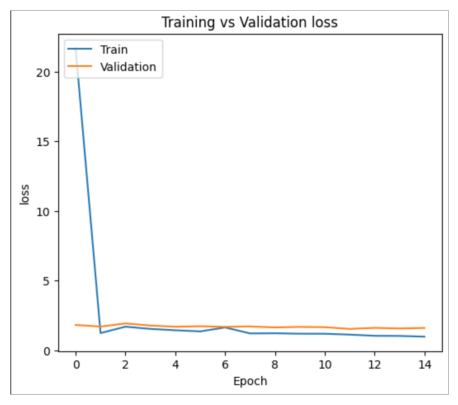

Displaying: Model 4_CM.png


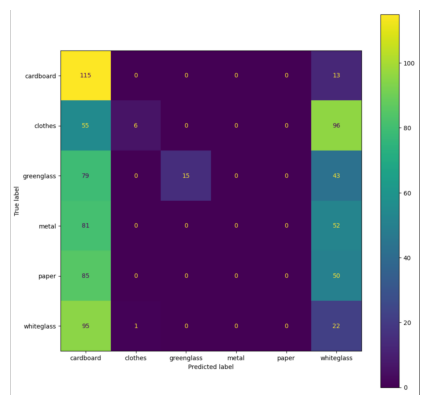

Displaying: Model 4_TrainvsTestAccuracy.png


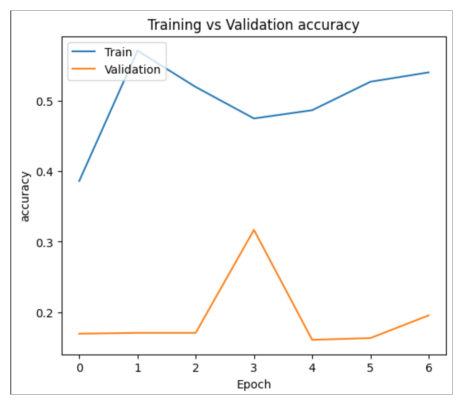

Displaying: Model 4_TrainvsTestLoss.png


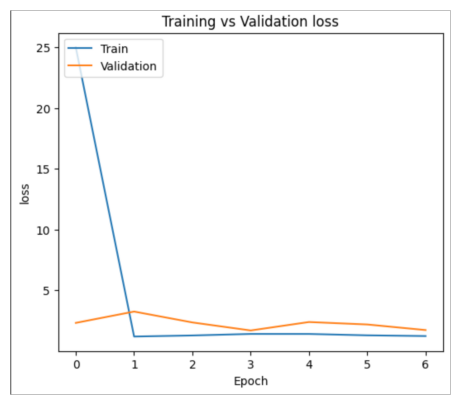

Displaying: Model 5_CM.png


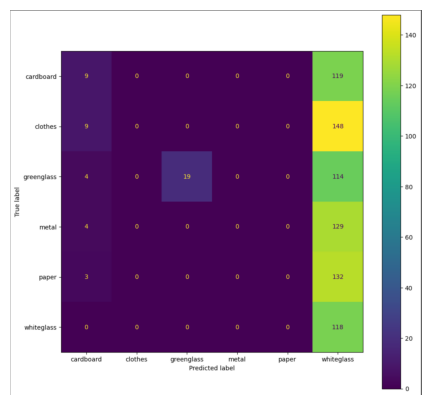

Displaying: Model 5_TrainvsTestAccuracy.png


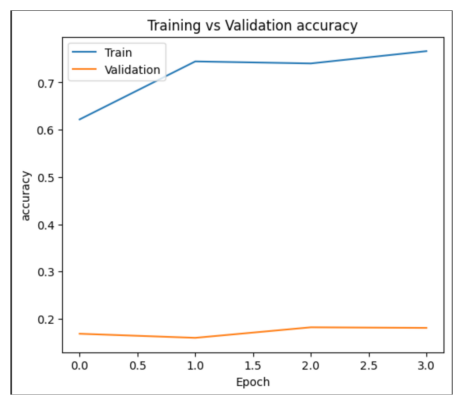

Displaying: Model 5_TrainvsTestLoss.png


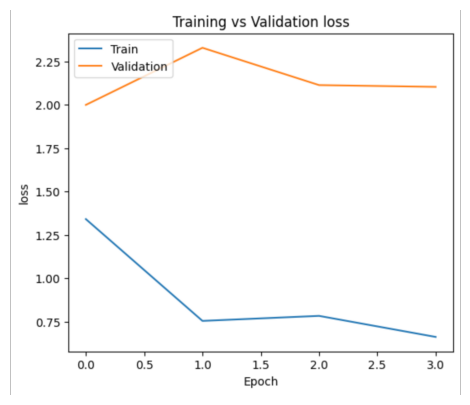

Displaying: Model 6_CM.png


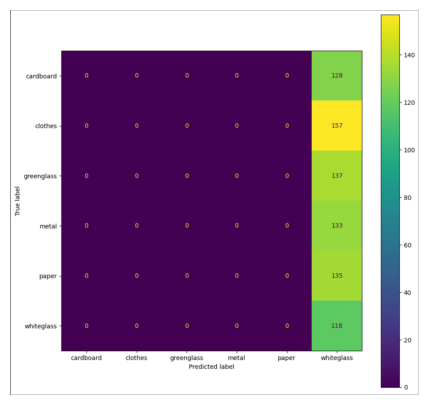

Displaying: Model 6_TrainvsTestAccuracy.png


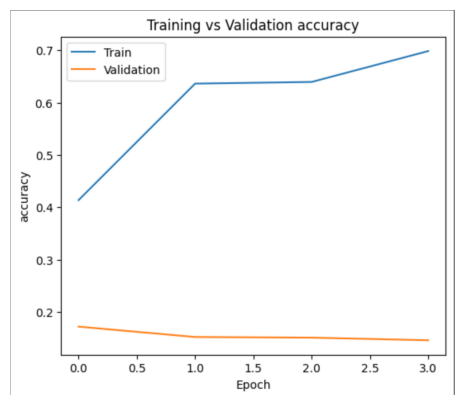

Displaying: Model 6_TrainvsTestLoss.png


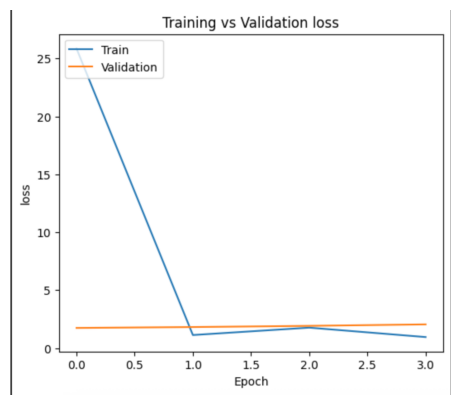

Displaying: Model 7_CM.png


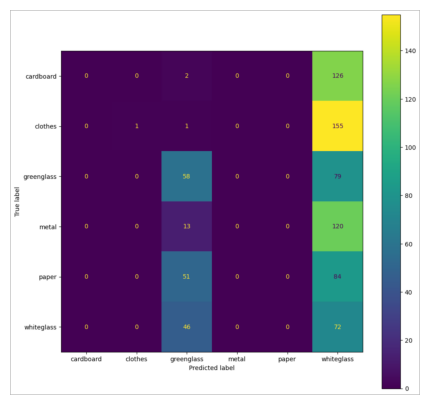

Displaying: Model 7_TrainvsTestAccuracy.png


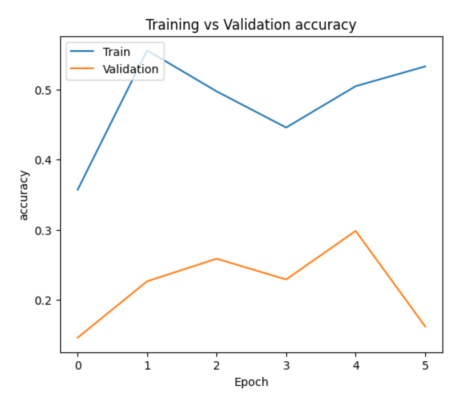

Displaying: Model 7_TrainvsTestLoss.png


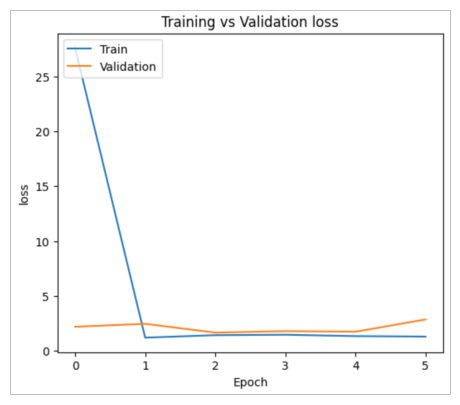

Displaying: Model 8_CM.png


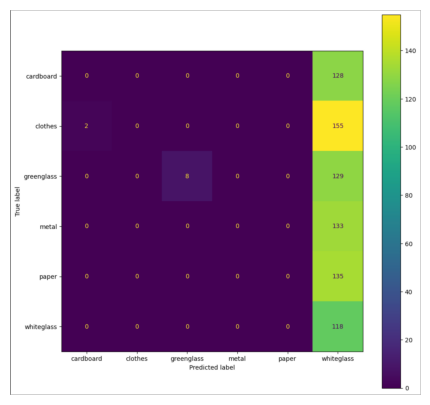

Displaying: Model 8_TrainvsTestAccuracy.png


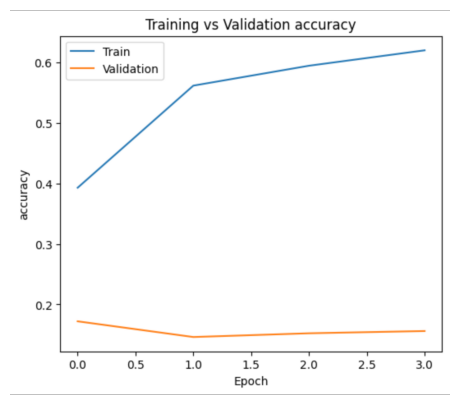

Displaying: Model 8_TrainvsTestLoss.png


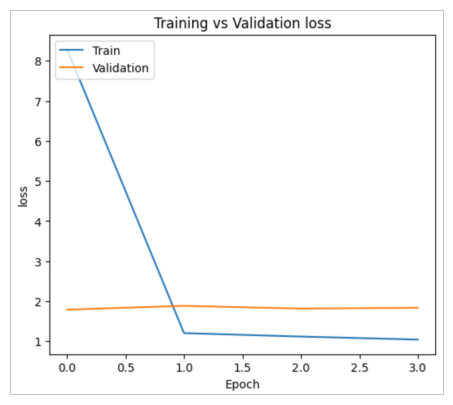

Displaying: Model 9_CM.png


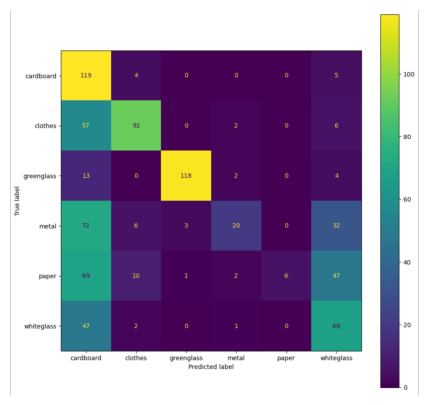

Displaying: Model 9_TrainvsTestAccuracy.png


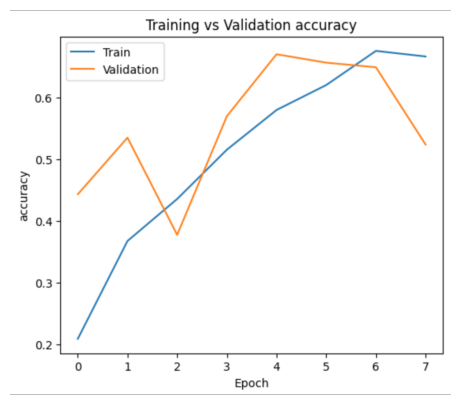

Displaying: Model 9_TrainvsTestLoss.png


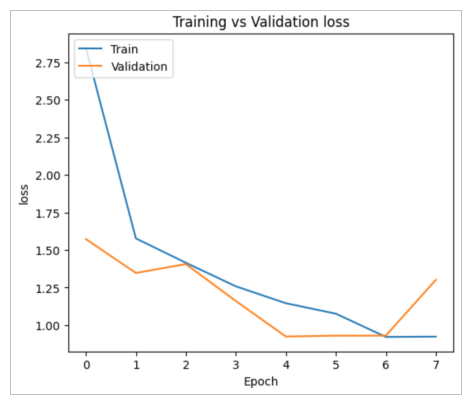

Displaying: Model 10_CM.png


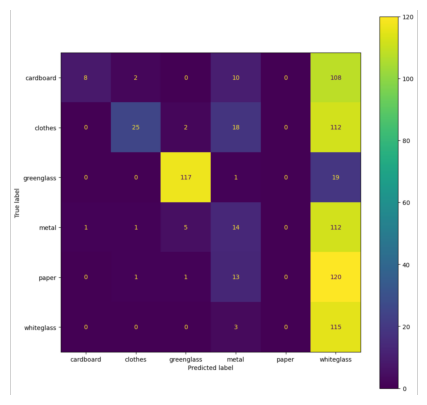

Displaying: Model 10_TrainvsTestAccuracy.png


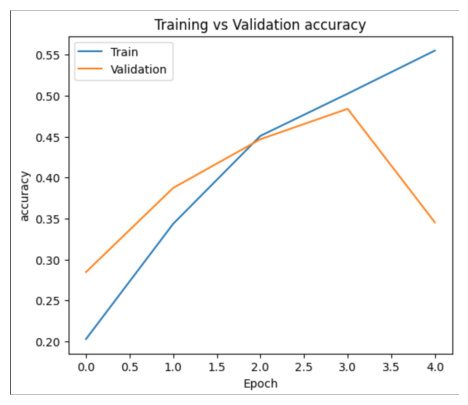

Displaying: Model 10_TrainvsTestLoss.png


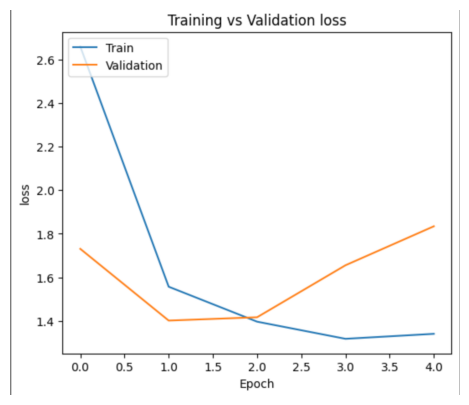

Displaying: Model 11_CM.png


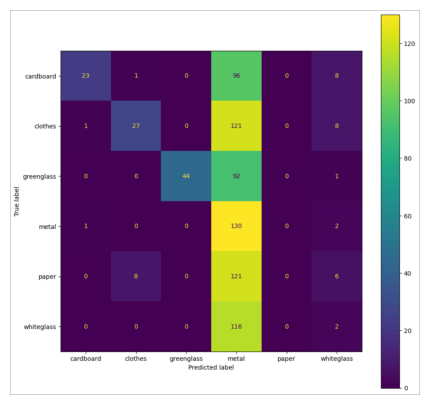

Displaying: Model 11_TrainvsTestAccuracy.png


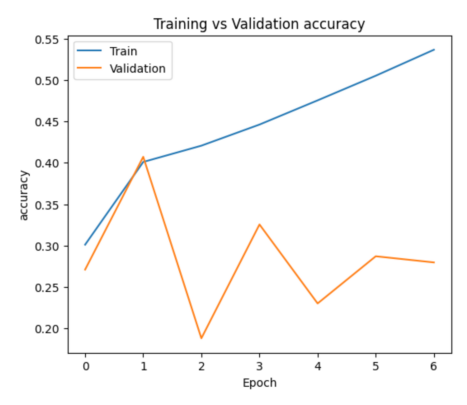

Displaying: Model 11_TrainvsTestLoss.png


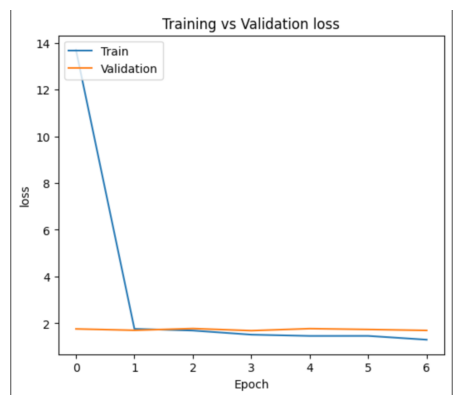

Displaying: Model 12_CM.png


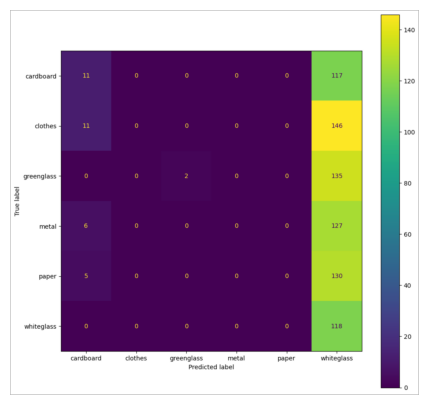

Displaying: Model 12_TrainvsTestAccuracy.png


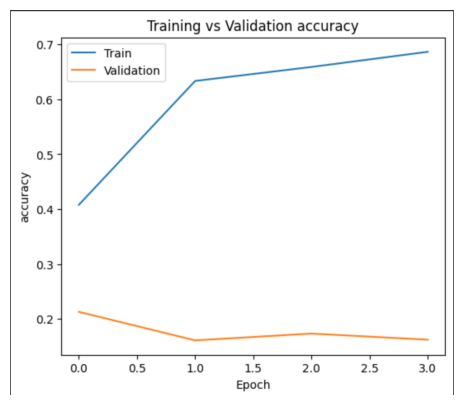

Displaying: Model 12_TrainvsTestLoss.png


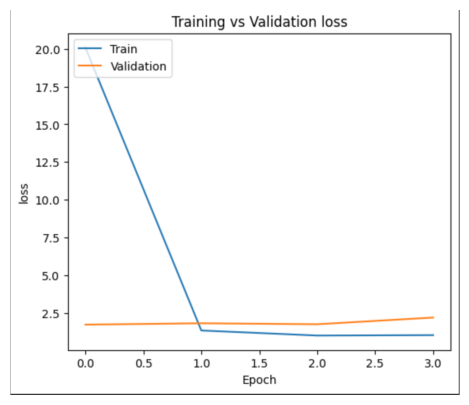

Displaying: Model 13_CM.png


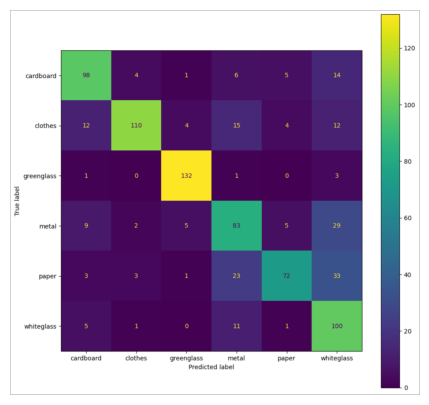

Displaying: Model 13_TrainvsTestAccuracy.png


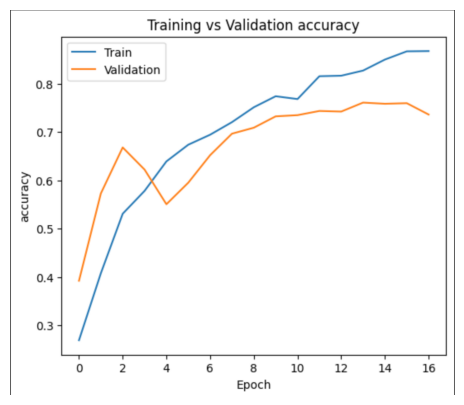

Displaying: Model 13_TrainvsTestLoss.png


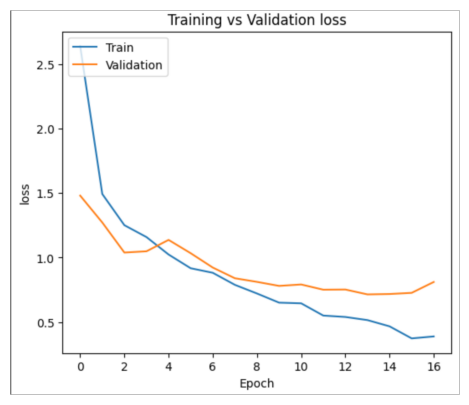

Displaying: Model 14_CM.png


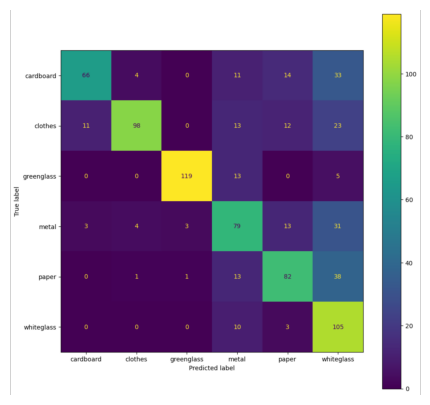

Displaying: Model 14_TrainvsTestAccuracy.png


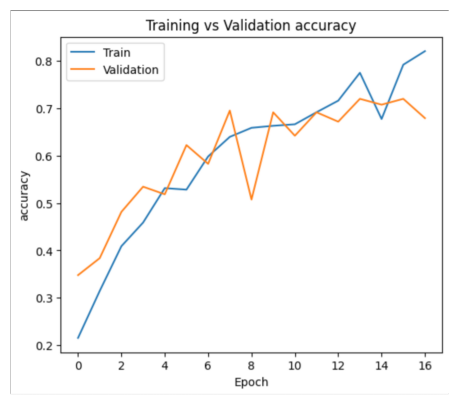

Displaying: Model 14_TrainvsTestLoss.png


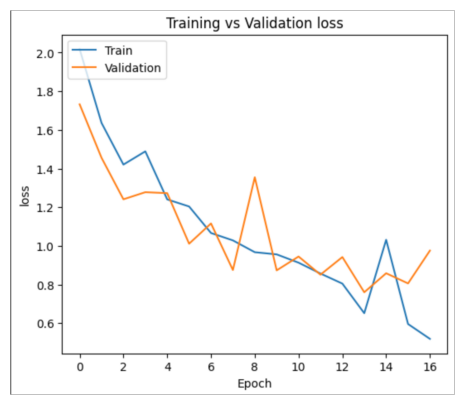

Displaying: Model 15_CM.png


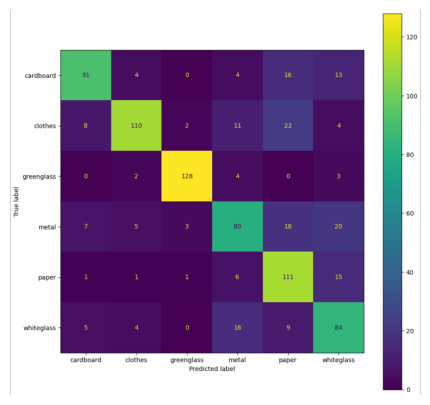

Displaying: Model 15_TrainvsTestAccuracy.png


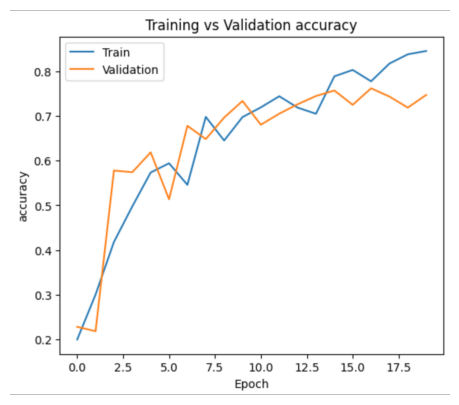

Displaying: Model 15_TrainvsTestLoss.png


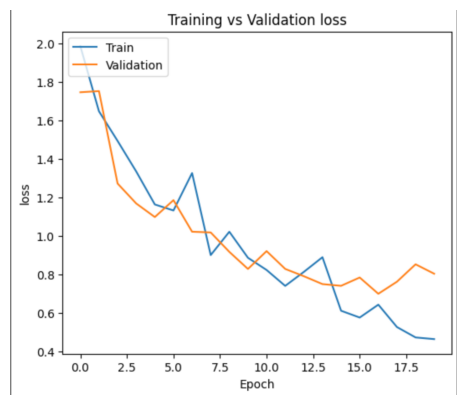

In [28]:
import re
# Get uploaded files
image_files = list(upload.keys())
def extract_order(fname):
    if fname.startswith("Model"):
        m = re.search(r"Model\s+(\d+)", fname)
        num = int(m.group(1)) if m else 999
    else:
        num = 1000
    return (num, fname)

# Sort based on model number first, then filename
image_files_sorted = sorted(image_files, key=extract_order)

# Display in order
for file_name in image_files_sorted:
    print(f"Displaying: {file_name}")
    fig, ax = plt.subplots()
    img = plt.imread(file_name)
    ax.imshow(img)
    ax.axis('off')
    plt.show()

Across the 15 models, the confusion matrices highlight consistent trends in class-level performance. Some models performed very poorly, collapsing to predict almost all samples as a single category, indicating weak feature extraction and confirming their low test accuracy.

For the stronger models, green glass was generally the easiest class to recognize, with most matrices showing high precision and recall. Its distinct color and shape features likely contributed to reliable classification. Cardboard and clothes also achieved relatively high accuracy in better-performing models.  In contrast, white glass, paper, and metal consistently underperformed.

While the final model (CNN-DoubleConv-MP-30-60-90-Flat-120D-Dr0.5) provided the most balanced and accurate predictions, misclassifications persisted for classes with overlapping visual characteristics. This underlines the challenge of recycling automation, where ambiguous material properties can cause systematic errors.

### Business Implication and Potential Improvements

For recycling facilities, accurate material classification is vital to reduce contamination and improve sorting efficiency. By achieving over 74% test accuracy and high agreement across most classes, the final model provides a practical foundation for supporting automated sorting systems. This can reduce human sorting effort, lower processing costs, and increase the overall effectiveness of recycling streams. However, before deployment, facilities must consider hardware integration, such as camera quality, real-time inference speed, and the cost of maintaining a reliable model in production.

Although the chosen model performed strongly, several approaches could further improve accuracy and robustness:

*   Data collection: Expanding the dataset with more diverse images, particularly for white glass and metal, would reduce misclassification caused by limited training examples.
*   Data augmentation: Applying transformations such as brightness adjustment, rotation, or background variation would help the model generalize better under real-world conditions.
*   Data formatting: Incorporating higher-resolution images may capture finer features, especially important for materials with subtle textures.

<a id = "cell_report"></a>
## 5. Role of GenAI


Generative AI was used as a collaborative assistant during the model development stage. Its main contributions were to:

*   Provide ideas for possible network architectures.
*   Suggest Python code for organizing and uploading experimental images in sequence for reporting, as well as for tasks not explicitly covered in the Lab materials.
*   Assist in troubleshooting coding issues that fell outside the scope of the provided resources.

AI support was limited to these supplementary tasks. The key elements of model development, experimentation, and analysis were carried out independently. All AI-generated suggestions were carefully reviewed and adapted to meet academic requirements. The final work and critical reflections remain my own.

## Reference

Deakin University 2025, *MIS780 Week 5 Lab – Part 1: Convolutional Neural Network*, CloudDeakin, Deakin University, accessed 1 September 2025.

Deakin University 2025, *MIS780 Week 5 Lab - Part 2: Convolutional Neural Network*, CloudDeakin, Deakin University, accessed 1 September 2025.